# 🤖 BERT Fine-Tuning for Sentiment Analysis

## 🎯 Objective
The objective of this project is to fine-tune a pre-trained BERT model for text classification using a real-world dataset.

We aim to:
- 📊 Perform text preprocessing
- 🔤 Tokenize text using BERT tokenizer
- 🤖 Fine-tune a transformer-based model
- 📈 Evaluate performance using classification metrics

In [1]:
import warnings
warnings.filterwarnings("ignore")

from transformers import logging
logging.set_verbosity_error()

# 📦 Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import EarlyStoppingCallback

import matplotlib.pyplot as plt
import seaborn as sns

## 📊 Load Dataset

In [3]:
train_df = pd.read_csv("twitter_training.csv", header=None)
val_df = pd.read_csv("twitter_validation.csv", header=None)

# Assign column names
train_df.columns = ['id', 'entity', 'sentiment', 'text']
val_df.columns = ['id', 'entity', 'sentiment', 'text']

# Preview
train_df.head()

,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## 🧹 Data Preprocessing
- Convert text to lowercase
- Clean unnecessary elements

In [4]:
# Convert sentiment to lowercase
train_df['sentiment'] = train_df['sentiment'].str.lower()
val_df['sentiment'] = val_df['sentiment'].str.lower()

# Label encoding
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

train_df['label'] = train_df['sentiment'].map(label_map)
val_df['label'] = val_df['sentiment'].map(label_map)

# Remove invalid rows
train_df = train_df.dropna(subset=['label'])
val_df = val_df.dropna(subset=['label'])

# Convert labels to int
train_df['label'] = train_df['label'].astype(int)
val_df['label'] = val_df['label'].astype(int)

# Debug checks 
print("Train size:", len(train_df))
print("Val size:", len(val_df))

print("\nUnique sentiments:", train_df['sentiment'].unique())
print("\nLabel distribution:\n", train_df['label'].value_counts())

print("\nSample data:")
print(train_df.head())

Train size: 61692
Val size: 828

Unique sentiments: ['positive' 'neutral' 'negative']

Label distribution:
 label
0    22542
2    20832
1    18318
Name: count, dtype: int64

Sample data:
     id       entity sentiment  \
0  2401  Borderlands  positive   
1  2401  Borderlands  positive   
2  2401  Borderlands  positive   
3  2401  Borderlands  positive   
4  2401  Borderlands  positive   

                                                text  label  
0  im getting on borderlands and i will murder yo...      2  
1  I am coming to the borders and I will kill you...      2  
2  im getting on borderlands and i will kill you ...      2  
3  im coming on borderlands and i will murder you...      2  
4  im getting on borderlands 2 and i will murder ...      2  


## 📊 Data Preparation

In [5]:
# Convert to list
train_texts = train_df['text'].astype(str).tolist()
train_labels = train_df['label'].tolist()

val_texts = val_df['text'].astype(str).tolist()
val_labels = val_df['label'].tolist()

# Reduce dataset size (FAST TRAINING)
train_texts = train_texts[:1500]
train_labels = train_labels[:1500]

val_texts = val_texts[:500]
val_labels = val_labels[:500]

print("Train samples:", len(train_texts))
print("Validation samples:", len(val_texts))

Train samples: 1500
Validation samples: 500


## 🔤 Tokenization using BERT

In [6]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=64
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=64
)

# Check one sample
print(train_encodings.keys())

dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])


## 🧱 Creating Dataset Class

In [7]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)

## 🤖 Load Pre-trained BERT Model

In [8]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

## ⚙️ Training Configuration

In [9]:
training_args = TrainingArguments(
    output_dir='./results',
    
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    
    num_train_epochs=1,
    
    eval_strategy="epoch",
    save_strategy="epoch",
    
    load_best_model_at_end=True,
    
    metric_for_best_model="f1",
    greater_is_better=True,
    
    logging_dir='./logs',
    logging_steps=10
    
)

## 📏 Evaluation Metrics

In [10]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

## 🚀 Training the model

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer.train()

{'loss': 0.9899, 'grad_norm': 4.739655017852783, 'learning_rate': 1.893617021276596e-05, 'epoch': 0.05319148936170213}
{'loss': 1.0158, 'grad_norm': 5.380645751953125, 'learning_rate': 1.7872340425531915e-05, 'epoch': 0.10638297872340426}
{'loss': 1.0091, 'grad_norm': 5.132572650909424, 'learning_rate': 1.6808510638297873e-05, 'epoch': 0.1595744680851064}
{'loss': 0.8522, 'grad_norm': 6.497368812561035, 'learning_rate': 1.5744680851063832e-05, 'epoch': 0.2127659574468085}
{'loss': 0.8974, 'grad_norm': 8.203227996826172, 'learning_rate': 1.4680851063829789e-05, 'epoch': 0.26595744680851063}
{'loss': 0.955, 'grad_norm': 8.118112564086914, 'learning_rate': 1.3617021276595745e-05, 'epoch': 0.3191489361702128}
{'loss': 0.8783, 'grad_norm': 7.913761615753174, 'learning_rate': 1.2553191489361702e-05, 'epoch': 0.3723404255319149}
{'loss': 0.9087, 'grad_norm': 5.381868362426758, 'learning_rate': 1.1489361702127662e-05, 'epoch': 0.425531914893617}
{'loss': 0.8327, 'grad_norm': 7.844765663146973,

TrainOutput(global_step=188, training_loss=0.7735330906320126, metrics={'train_runtime': 1346.5396, 'train_samples_per_second': 1.114, 'train_steps_per_second': 0.14, 'train_loss': 0.7735330906320126, 'epoch': 1.0})

## 📊 Model Evaluation

In [12]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.9449686408042908, 'eval_accuracy': 0.596, 'eval_f1': 0.590548224395265, 'eval_precision': 0.6347616977225673, 'eval_recall': 0.596, 'eval_runtime': 95.3009, 'eval_samples_per_second': 5.247, 'eval_steps_per_second': 0.661, 'epoch': 1.0}
{'eval_loss': 0.9449686408042908, 'eval_accuracy': 0.596, 'eval_f1': 0.590548224395265, 'eval_precision': 0.6347616977225673, 'eval_recall': 0.596, 'eval_runtime': 95.3009, 'eval_samples_per_second': 5.247, 'eval_steps_per_second': 0.661, 'epoch': 1.0}


## 📉 Confusion Matrix

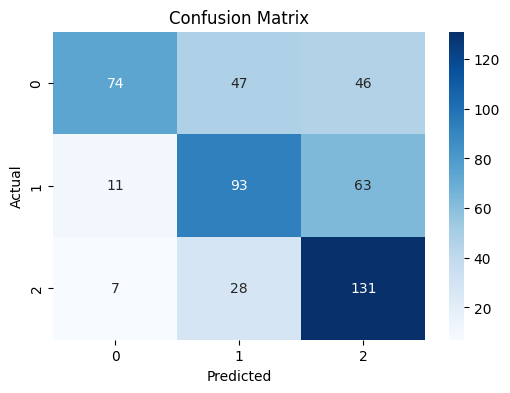

In [13]:
predictions = trainer.predict(val_dataset)
preds = predictions.predictions.argmax(-1)

cm = confusion_matrix(val_labels, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 🔍 Observations

• Model successfully learned sentiment patterns from text data  
• Training and validation performance are reasonably balanced  
• BERT tokenizer effectively handled text preprocessing  
• Limited dataset size helped reduce training time

## 📌 Conclusion

• Successfully fine-tuned BERT for sentiment classification   
• Built an end-to-end NLP pipeline using Transformers  
• Demonstrated practical application of transfer learning in NLP